# Fetching and extracting data from the MNIST dataset 

- Dataloader delivers data in batches 
- Batch sizes are specified through the batch_size parameter in constructor 
- Training data is delivered in batches of 64 and test data is delivered in batches of 1000 images 

In [210]:
import torch
import torchvision

train_batch_size = 64
test_batch_size  = 1000


def get_data_loaders():
    train_loader = torch.utils.data.DataLoader(
        torchvision.datasets.MNIST('/files/', train=True, download=True,
                                 transform=torchvision.transforms.Compose([
                                   torchvision.transforms.ToTensor(),
                                   torchvision.transforms.Normalize(
                                     (0.1307,), (0.3081,))
                                 ])),
        batch_size=train_batch_size, shuffle=True)

    test_loader = torch.utils.data.DataLoader(
        torchvision.datasets.MNIST('/files/', train=False, download=True,
                                transform=torchvision.transforms.Compose([
                                    torchvision.transforms.ToTensor(),
                                    torchvision.transforms.Normalize(
                                    (0.1307,), (0.3081,))
                                ])),
        batch_size=test_batch_size, shuffle=True)
    
    
    return train_loader, test_loader 

train_loader, test_loader = get_data_loaders()




# Examining and displaying content of loaded data

The following is a basic method to select any arbitrary image from any arbitrary batch. 

In [211]:
import math 

def get_img_and_label(batch_idx, img_idx):
    
    batch_count = math.ceil(len(test_loader.dataset) / test_loader.batch_size) 
    if batch_idx >= batch_count:
        print(f"Batch index {batch_idx} out of range. Max batch index is {batch_count - 1}.")
        return None, None
    
    batch_dataset = enumerate(test_loader)
    for cur_batch_idx, (batch_images, batch_labels) in batch_dataset:
        if cur_batch_idx == batch_idx:
            if img_idx >= batch_images.size(0):
                print(f"Image index {img_idx} out of range for batch {batch_idx}. Max image index is {batch_images.size(0) - 1}.")
                return None, None
            
            img = batch_images[img_idx]
            label = batch_labels[img_idx].item() 
            return img, label
        
    # Defensive return in case of unexpected failure 
    return None, None

Printing the training labels in the first batch. 

In [212]:
train_loader, test_loader = get_data_loaders()


batch_dataset = enumerate(train_loader)
batch_idx, (batch_images, batch_labels) = next(batch_dataset)


print("Digits contained in the first training batch:")
print(batch_labels)

Digits contained in the first training batch:
tensor([8, 0, 4, 4, 2, 0, 5, 6, 9, 0, 0, 1, 6, 6, 4, 0, 5, 6, 4, 3, 0, 7, 2, 3,
        2, 3, 5, 8, 4, 4, 7, 9, 0, 3, 9, 0, 7, 6, 0, 3, 4, 4, 7, 9, 2, 4, 1, 4,
        7, 5, 9, 4, 7, 8, 9, 7, 4, 7, 2, 2, 6, 6, 6, 5])


Selecting 6 arbitrary images from test data and displaying them

Selecting Image 551 from Test Batch 5
Selecting Image 154 from Test Batch 3
Selecting Image 144 from Test Batch 4
Selecting Image 283 from Test Batch 5
Selecting Image 990 from Test Batch 3
Selecting Image 464 from Test Batch 3


C:\Users\pubal\AppData\Local\Temp\ipykernel_17880\1469634671.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


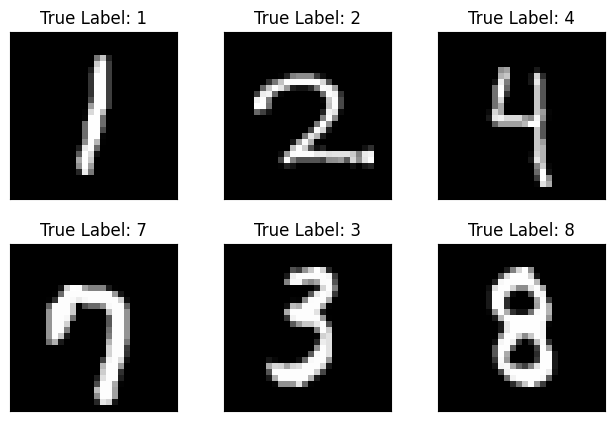

In [213]:
import matplotlib.pyplot as plt

fig = plt.figure()


img_arr = []
label_arr = []
for epoch in range(6):

  batch_idx = torch.randint(0, math.ceil(len(test_loader.dataset) / test_loader.batch_size), (1,)).item()
  img_idx   = torch.randint(0, test_loader.batch_size, (1,)).item()
  
  print(f'Selecting Image {img_idx} from Test Batch {batch_idx}')
  
  image, label = get_img_and_label(batch_idx, img_idx)
  img_arr.append(image)
  label_arr.append(label)

for epoch in range(6):
  plt.subplot(2,3,epoch+1)
  plt.tight_layout()
  
  image, label = get_img_and_label(batch_idx, img_idx) 
  plt.imshow(img_arr[epoch].squeeze(), cmap='gray', interpolation='none')
  plt.title("True Label: {}".format(label_arr[epoch]))
  plt.xticks([])
  plt.yticks([])
  
fig.show() 

# Construction of the NN

- 2 Convolutional neural networks (with max pooling)
- 1 Dropout layer 
- 2 Fully connected layers 


The NN is parameterizable. 

In [214]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ParamCNN(nn.Module):
    
    # Public constructor with parameters for layers and sizes 
    def __init__(self,
                 input_size=(28, 28),
                 conv1_out_channels=10,
                 conv2_out_channels=20,
                 conv_kernel_size=5,
                 pool_kernel_size=2,
                 fc1_out_features=50):
        super(ParamCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, conv1_out_channels, kernel_size=conv_kernel_size)
        self.conv2 = nn.Conv2d(conv1_out_channels, conv2_out_channels, kernel_size=conv_kernel_size)
        self.conv2_drop = nn.Dropout2d()
        
        # Pooling size
        self.pool_kernel_size = pool_kernel_size

        # Dynamically compute flattened feature size for fc1
        self.feature_size = self._get_feature_size(input_size, conv_kernel_size, pool_kernel_size, conv1_out_channels, conv2_out_channels)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.feature_size, fc1_out_features)
        self.fc2 = nn.Linear(fc1_out_features, 10) # This output is not configurable - there are only 10 digits 


    # Override forward method 
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), self.pool_kernel_size))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), self.pool_kernel_size))
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)
    
    # Private method to compute feature size after conv and pool layers 
    def _get_feature_size(self, input_size, conv_kernel_size, pool_kernel_size, conv1_out, conv2_out):
        h, w = input_size

        # After conv1
        h = h - conv_kernel_size + 1
        w = w - conv_kernel_size + 1
        # After pool1
        h = h // pool_kernel_size
        w = w // pool_kernel_size

        # After conv2
        h = h - conv_kernel_size + 1
        w = w - conv_kernel_size + 1
        # After pool2
        h = h // pool_kernel_size
        w = w // pool_kernel_size

        # Number of features = channels * height * width
        return conv2_out * h * w



# A wrapper class for experimentation 

The classifier wrapper class stores the ParamNN parameters and performs both training and test. All the parameters of the NN are class members of the wrapper. 
Additionally, the training can be executed upto a certain number of epochs or can be continued upto a certain accuracy level is reached. 

In [215]:
class MnistClassifier:
    
    logging_interval = 100 
    max_epoch_iter = 20
    
    
    def __init__(self):
        self.input_size=(28, 28)
        self.conv1_out_channels=10
        self.conv2_out_channels=20
        self.conv_kernel_size=5
        self.pool_kernel_size=2
        self.fc1_out_features=50
        self.model = None 
        
        # The classifier is to be initialized either to run for a fixed 
        # number of epochs or to reach a target accuracy. 
        # If default values are noz overriden, training will not run  
        self.epochs = 0
        self.target_accuracy = 0.0 
        
        # After training the executed epochs and final accuracy 
        self.executed_epochs = 0
        self.obtained_accuracy = 0.0 
        
        
    def _init_model(self):
        self.model = ParamCNN(
            input_size=self.input_size,
            conv1_out_channels=self.conv1_out_channels,
            conv2_out_channels=self.conv2_out_channels,
            conv_kernel_size=self.conv_kernel_size,
            pool_kernel_size=self.pool_kernel_size,
            fc1_out_features=self.fc1_out_features
        )
        
        torch.backends.cudnn.enabled = False
        torch.manual_seed(1)
        self.optimizer = optim.SGD(self.model.parameters(), lr=0.01, momentum=0.5)
        self.criterion = nn.NLLLoss()
    
    def _train(self, epoch):
        
        print(f'*** Starting a new round of training for Epoch {epoch} ***\n')
        self.model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            self.optimizer.zero_grad()
            output = self.model(data)
            loss = F.nll_loss(output, target)
            loss.backward()
            self.optimizer.step()
            if batch_idx % MnistClassifier.logging_interval == 0:
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, batch_idx * len(data), len(train_loader.dataset),
                    100. * batch_idx / len(train_loader), loss.item()))
                
                torch.save(self.model.state_dict(), './results/model.pth')
                torch.save(self.optimizer.state_dict(), './results/optimizer.pth')
    
    def _test(self):
        
        test_loss = 0
        correct = 0 
        test_dataset_size = len(test_loader.dataset)
        
        self.model.eval()
        with torch.no_grad():
            for data, target in test_loader:
                output = self.model(data)
                test_loss += F.nll_loss(output, target, size_average=False).item()
                pred = output.data.max(1, keepdim=True)[1]
                correct += pred.eq(target.data.view_as(pred)).sum()
        test_loss /= test_dataset_size
        
        accuracy = 100. * correct / test_dataset_size
        print(f'\n*** Test set: Avg. loss: {test_loss:.4f}, Accuracy: {correct}/{test_dataset_size} ({accuracy:.2f}) *** \n\n')
        
        return accuracy 
        
    
    def train_and_test(self):
        
        if self.epochs <= 0 and self.target_accuracy <= 0.0:
            print("Number of epochs AND target accuracy both undefined. No training will be run")
            return
        
        # Start training  
        self._init_model() 
        accuracy = 0
    
        # Epochs have priority if specified 
        if self.epochs > 0:
            for epoch in range(1, self.epochs + 1):
                self._train(epoch)
                accuracy = self._test()
            
            self.executed_epochs = self.epochs 
            self.obtained_accuracy = accuracy 
        else:
            # Check if the number is between 0 and 100 
            if self.target_accuracy > 100: 
                print(f"Target accuracy {self.target_accuracy} exceeds hundred percent. Will set 99.5% accuracy")
                self.target_accuracy = 99.5 
            
            # Will run maximum of 20 epochs
            for epoch in range(1, MnistClassifier.max_epoch_iter + 1):
                self._train(epoch)
                accuracy = self._test() 
                
                if accuracy > self.target_accuracy:
                    self.executed_epochs = epoch 
                    self.obtained_accuracy = accuracy 
                    
                    print(f'\n*** Achieved target accuracy after {self.executed_epochs} epochs ***')
                    break

Classification upto 5 epochs 

In [191]:
classifier = MnistClassifier() 

classifier.epochs = 5
classifier.train_and_test() 

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.337264
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.930429
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.124613
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.715437
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.905413
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.470908
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.606641
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.373323
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.457288
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.443718

Test set: Avg. loss: 0.1901, Accuracy: 9453/10000 (94.53)
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.424698
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.458506
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.535372
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.391989
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.421964
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.315613
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.294850
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.204549
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.528710
Tra

Classification upto 96% accuracy 

In [203]:
classifier = MnistClassifier() 

classifier.target_accuracy = 96
classifier.train_and_test() 

*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303832
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.967146
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.892927
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.720714
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.815432
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.424689
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.568235
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.541586
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.607692
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.524419


c:\Users\pubal\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



*** Test set: Avg. loss: 0.1935, Accuracy: 9409/10000 (94.09) *** 


*** Starting a new round of training for Epoch 2 ***

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.432859
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.312180
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.495362
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.285672
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.391159
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.384298
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.221492
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.291076
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.342164
Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.334633

*** Test set: Avg. loss: 0.1245, Accuracy: 9614/10000 (96.14) *** 



*** Achieved target accuracy after 2 epochs ***


# Peforming test prediction 

- A basic function that performs prediction for a given image 
- Calling this method with random indices from random batches 

In [206]:
def perform_prediction(classifier, batch_idx, img_idx, display=False):

    # Ensure model is in evaluation mode
    
    model = classifier.model
    model.eval()
    
    image, label = get_img_and_label(batch_idx, img_idx)
    
    if image is None:
        return
    
    image_batch = image.unsqueeze(0)

    # Run prediction
    with torch.no_grad():
        output = model(image_batch)
        predicted_class = output.argmax(dim=1).item()


    success = label == predicted_class
    if success:
        print(f"Success: Actual and Predicated label: {label}")
    else:
        print(f"Failure: Actual {label} vs. Predicted {predicted_class} ")
    
    # Display the image
    if display:
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f"Predicted: {predicted_class} | Actual: {label}")
        plt.axis('off')
        plt.show()

In [208]:

for epoch in range(20):
    batch_idx = torch.randint(0, math.ceil(len(test_loader.dataset) / test_loader.batch_size), (1,)).item()
    img_idx = torch.randint(0, test_loader.batch_size, (1,)).item()
    print(f"\nTrial: Batch {batch_idx}, Image {img_idx}")
    perform_prediction(classifier, batch_idx, img_idx, display=False)




Trial: Batch 4, Image 565
Success: Actual and Predicated label: 5

Trial: Batch 2, Image 65
Failure: Actual 5 vs. Predicted 3 

Trial: Batch 3, Image 571
Success: Actual and Predicated label: 8

Trial: Batch 3, Image 914
Success: Actual and Predicated label: 5

Trial: Batch 2, Image 233
Success: Actual and Predicated label: 1

Trial: Batch 2, Image 478
Success: Actual and Predicated label: 2

Trial: Batch 8, Image 567
Success: Actual and Predicated label: 9

Trial: Batch 6, Image 743
Failure: Actual 7 vs. Predicted 9 

Trial: Batch 3, Image 620
Success: Actual and Predicated label: 8

Trial: Batch 0, Image 957
Success: Actual and Predicated label: 9

Trial: Batch 5, Image 853
Success: Actual and Predicated label: 5

Trial: Batch 0, Image 393
Success: Actual and Predicated label: 7

Trial: Batch 6, Image 838
Success: Actual and Predicated label: 9

Trial: Batch 4, Image 186
Success: Actual and Predicated label: 5

Trial: Batch 1, Image 16
Success: Actual and Predicated label: 4

Trial:

# Testing parameters of the classifier 

Benchmarking the parameters of the model. The number of outputs of the first fully connected layer is varied from 25 to 75 with steps of 5 and the model is trained for one single epoch. The accuracies obtained are plotted.  

In [216]:
conn_vec = []
acc_vec = []

for i in range(25, 75 + 5, 5):
    classifier = MnistClassifier()
    classifier.fc1_out_features = i 
    classifier.epochs = 1 
    
    classifier.train_and_test()
    
    conn_vec.append(i)
    acc_vec.append(classifier.obtained_accuracy)
    
    print(f'*** FC1 Size: {i} Accuracy: {classifier.obtained_accuracy} ***')
    
    

*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.391486
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.986697
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.423096
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.138798
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.951184
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.809065
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.651090
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.736303
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.834366
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.707681


c:\Users\pubal\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



*** Test set: Avg. loss: 0.2371, Accuracy: 9359/10000 (93.59) *** 


*** FC1 Size: 25 Accuracy: 93.58999633789062 ***
*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.295817
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.942966
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.227323
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.933563
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.114693
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.600598
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.664394
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.471991
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.634499
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.505882

*** Test set: Avg. loss: 0.2063, Accuracy: 9398/10000 (93.98) *** 


*** FC1 Size: 30 Accuracy: 93.9800033569336 ***
*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.301221
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.071180
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.282052
Train Epoch: 1 [1

C:\Users\pubal\AppData\Local\Temp\ipykernel_17880\1998121008.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


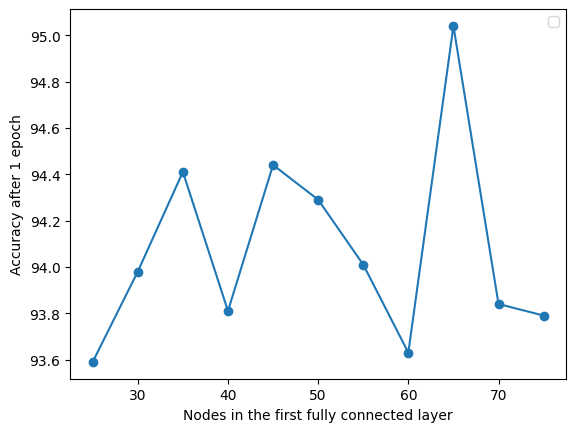

In [ ]:
plt.plot(conn_vec, acc_vec, marker='o', linestyle='-', label='')

# Step 3: Add labels and title
plt.xlabel('Nodes in the first fully connected layer')
plt.ylabel('Accuracy after 1 epoch')
plt.title('Nodes in first FC vs. Accuracy')
plt.legend()

plt.show()

Now testing the same with number of output channels in conv1 and conv2 layers. The output is a 3-D scatter plot.

In [222]:
conv1_out = []
conv2_out = [] 
acc_vec = []

for i in range(10, 30, 5):
    for j in range(i + 10, i + 30, 5):
        classifier = MnistClassifier() 
        
        classifier.conv1_out_channels = i
        classifier.conv2_out_channels = j
        classifier.fc1_out_features = 100 
    
        
        # Run for 1 epoch only 
        classifier.epochs = 1
        classifier.train_and_test() 
        
        conv1_out.append(i)
        conv2_out.append(j)
        accuracy = classifier.obtained_accuracy 
        acc_vec.append(accuracy)
        
        print(f'*** Conv1 Out Channels: {i} Conv2 Out Channels: {j} Accuracy: {accuracy} ***')    
        

*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.318685
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.911449
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.975489
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.602100
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.797619
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.402125
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.614457
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.310659
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.360847
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.441794


c:\Users\pubal\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



*** Test set: Avg. loss: 0.1829, Accuracy: 9434/10000 (94.34) *** 


*** Conv1 Out Channels: 10 Conv2 Out Channels: 20 Accuracy: 94.33999633789062 ***
*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.258016
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.451183
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.818057
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.570520
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.679334
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.453635
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.468054
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.287112
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.500170
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.385616

*** Test set: Avg. loss: 0.1815, Accuracy: 9442/10000 (94.42) *** 


*** Conv1 Out Channels: 10 Conv2 Out Channels: 25 Accuracy: 94.41999816894531 ***
*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.307729
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.742367


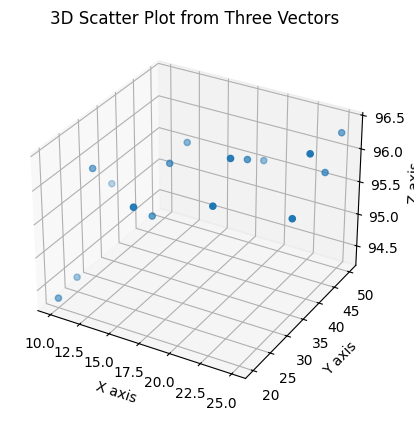

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Enables 3D projections
import numpy as np

# Example vectors
x = np.array(conv1_out)
y = np.array(conv2_out)
z = np.array(acc_vec)

# Create a figure
fig = plt.figure()

# Add a 3D axis
ax = fig.add_subplot(111, projection='3d')

# Create the scatter plot
ax.scatter3D(x, y, z, marker='o')

# Label the axes
ax.set_xlabel('Conv1 Out Channels')
ax.set_ylabel('Conv2 Out Channels')
ax.set_zlabel('Accuracy')
ax.set_title('Accuracy after 1 Epoch with various Conv1/2 Out channels')

# Show the plot
plt.show()


As a final experiment, the number of output channels of the second conv layer are varied from 40 to 100 while keeping the number of conv1 out channels = 25 and number of nodes in the FC1 = 100. This is done because the scatter plot indicates that the number of conv2 outputs have some positive correlation with accuracy. 

In [228]:
conv2_vec = []
acc_vec = []

for i in range(40, 100 + 5, 5):
    classifier = MnistClassifier()
    
    classifier.conv1_out_channels = 25 
    classifier.conv2_out_channels = i 
    classifier.fc1_out_features   = 100
    
    classifier.epochs = 1 
    classifier.train_and_test()
    
    conv2_vec.append(i)
    acc_vec.append(classifier.obtained_accuracy)
    
    print(f'*** Conv2 Out Channels: {i} Accuracy: {classifier.obtained_accuracy} ***')
    

*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.332592
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.201627
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.735482
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.575991
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.528108
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.293269
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.568411
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.197993
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.395903
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.192053


c:\Users\pubal\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



*** Test set: Avg. loss: 0.1329, Accuracy: 9597/10000 (95.97) *** 


*** Conv2 Out Channels: 40 Accuracy: 95.97000122070312 ***
*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.347858
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.142758
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.488952
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.326441
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.358478
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.213928
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.419366
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.205932
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.322150
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.162997

*** Test set: Avg. loss: 0.1268, Accuracy: 9590/10000 (95.90) *** 


*** Conv2 Out Channels: 45 Accuracy: 95.9000015258789 ***
*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.334062
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.273282
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.4657

C:\Users\pubal\AppData\Local\Temp\ipykernel_17880\2422728938.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


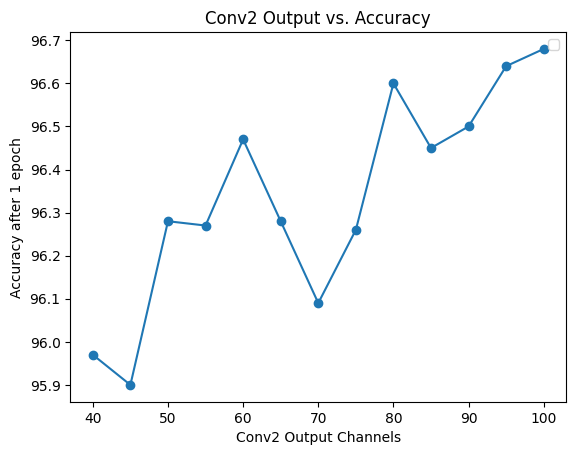

In [229]:
plt.plot(conv2_vec, acc_vec, marker='o', linestyle='-', label='')

# Step 3: Add labels and title
plt.xlabel('Conv2 Output Channels')
plt.ylabel('Accuracy after 1 epoch')
plt.title('Conv2 Output vs. Accuracy')
plt.legend()

plt.show()

And finally increasing Conv1 from 20 to 60 with Conv2 Out = 100 and FC1 Nodes = 100. 

In [231]:
conv1_vec = []
acc_vec = []

for i in range(10, 60 + 5, 5):
    classifier = MnistClassifier()
    
    classifier.conv1_out_channels = i 
    classifier.conv2_out_channels = 100
    classifier.fc1_out_features   = 100
    
    classifier.epochs = 1 
    classifier.train_and_test()
    
    conv1_vec.append(i)
    acc_vec.append(classifier.obtained_accuracy)
    
    print(f'*** Conv1 Out Channels: {i} Accuracy: {classifier.obtained_accuracy} ***')

*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.286917
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.942238
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.477462
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.399213
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.468092
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.243779
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.399182
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.203917
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.363901
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.326992

*** Test set: Avg. loss: 0.1171, Accuracy: 9627/10000 (96.27) *** 


*** Conv1 Out Channels: 10 Accuracy: 96.2699966430664 ***
*** Starting a new round of training for Epoch 1 ***

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.306886
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.939611
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.501598
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.326672
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.478852
Train Epoch: 1 [32000/6000

C:\Users\pubal\AppData\Local\Temp\ipykernel_17880\1636720808.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


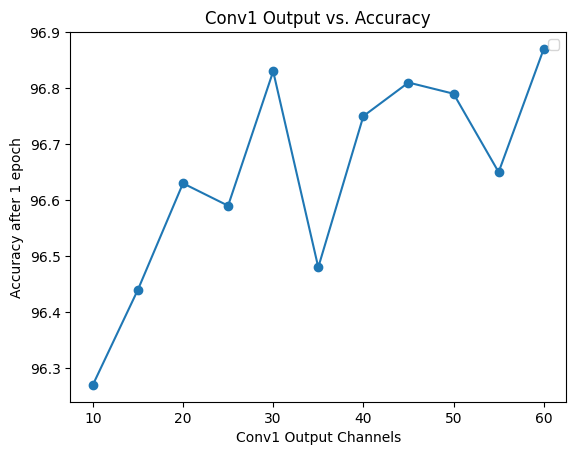

In [232]:
plt.plot(conv1_vec, acc_vec, marker='o', linestyle='-', label='')

# Step 3: Add labels and title
plt.xlabel('Conv1 Output Channels')
plt.ylabel('Accuracy after 1 epoch')
plt.title('Conv1 Output vs. Accuracy')
plt.legend()

plt.show()